In [36]:
import pandas as pd
import numpy as np
import os, os.path
import seaborn as sns
import tqdm
import matplotlib.pyplot as plt

In [37]:
data_path = "spotify_data/"

files = os.listdir(data_path)

In [38]:
files

['industrial.csv',
 'piano.csv',
 'power-pop.csv',
 'indie-pop.csv',
 'singer-songwriter.csv',
 'black-metal.csv',
 'r-n-b.csv',
 'soul.csv',
 'emo.csv',
 'trip-hop.csv',
 'disney.csv',
 'pop-film.csv',
 'ambient.csv',
 'guitar.csv',
 'kids.csv',
 'anime.csv',
 'comedy.csv',
 'minimal-techno.csv',
 'indie.csv',
 'house.csv',
 'metal.csv',
 'malay.csv',
 'j-idol.csv',
 'rock.csv',
 'progressive-house.csv',
 'british.csv',
 'dance.csv',
 'forro.csv',
 'turkish.csv',
 'gospel.csv',
 'blues.csv',
 'groove.csv',
 'sertanejo.csv',
 'deep-house.csv',
 'breakbeat.csv',
 'indian.csv',
 'README.md',
 'study.csv',
 'new-age.csv',
 'salsa.csv',
 'disco.csv',
 'opera.csv',
 'songwriter.csv',
 'funk.csv',
 'dancehall.csv',
 'children.csv',
 'alt-rock.csv',
 'swedish.csv',
 'chicago-house.csv',
 'j-pop.csv',
 'chill.csv',
 'electro.csv',
 'iranian.csv',
 'sleep.csv',
 'ska.csv',
 'mpb.csv',
 'dubstep.csv',
 'j-dance.csv',
 'honky-tonk.csv',
 'trance.csv',
 'grunge.csv',
 'rock-n-roll.csv',
 'reggae.c

In [39]:
print(files[0])
X = pd.read_csv(os.path.join( data_path, files[0] ))
X.info()

industrial.csv
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          1000 non-null   str    
 1   artists           1000 non-null   str    
 2   album_name        1000 non-null   str    
 3   track_name        1000 non-null   str    
 4   popularity        1000 non-null   int64  
 5   duration_ms       1000 non-null   int64  
 6   explicit          1000 non-null   bool   
 7   danceability      1000 non-null   float64
 8   energy            1000 non-null   float64
 9   key               1000 non-null   int64  
 10  loudness          1000 non-null   float64
 11  mode              1000 non-null   int64  
 12  speechiness       1000 non-null   float64
 13  acousticness      1000 non-null   float64
 14  instrumentalness  1000 non-null   float64
 15  liveness          1000 non-null   float64
 16  valence           1000 non-null   float

In [40]:
X.head(2)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,2naBVHNHinneXOYmczG7xE,Marilyn Manson,The Pale Emperor,Killing Strangers,55,336487,True,0.593,0.550,5,-5.946,1,0.0379,0.00989,0.000003,0.132,0.511,59.996,4,industrial
1,2302lUwfZ4S4dVyPOCDFnQ,Marilyn Manson,Smells Like Children,Sweet Dreams (Are Made Of This),70,293293,False,0.392,0.642,8,-5.267,1,0.0326,0.00480,0.486000,0.296,0.129,92.698,4,industrial


# Analiza twórczości Eminema
Pytania badawcze:
- Wulgarność, a popularność: Czy utwory zawierające wulgaryzmy są bardziej popularne?
- Styl flow: Jak zmieniał się wskaźnik obecności mowy w albumach i utworach eminema na przestrzeni lat?
- Emocje: Jakie emocje dominują w tekstach Eminema i jak się one zmieniają w czasie?

In [41]:
df_dict = {file: pd.read_csv(os.path.join(data_path, file)) for file in files}
df_dict.pop("README.md")

,**Źródło danych**
0,Maharshi Pandya. (2022). Spotify Tracks Datase...
1,Dane pierwotnie pozyskane z Spotify Web API
2,https://www.kaggle.com/datasets/maharshipandya...
3,Licencja: https://opendatacommons.org/licenses...


In [42]:
len(df_dict)

114

In [30]:
spotify_df = pd.concat(df_dict.values(), ignore_index=True)
eminem_df = spotify_df[spotify_df['artists'].str.contains('Eminem', na=False, case=False)]

In [33]:
eminem_df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1069,5W8HXMOMLtXLz0RGKUtnlZ,Skylar Grey;Polo G;Mozzy;Eminem,"Last One Standing (feat. Polo G, Mozzy & Emine...","Last One Standing (feat. Polo G, Mozzy & Emine...",73,257368,True,0.664,0.692,1,-4.128,0,0.127,0.237,0.000000,0.0798,0.233,154.924,4,piano
1173,3r9m79pHykbs4FrCXlq1oO,Skylar Grey;Polo G;Mozzy;Eminem,"Last One Standing (feat. Polo G, Mozzy & Emine...","Last One Standing (feat. Polo G, Mozzy & Emine...",54,258678,True,0.585,0.714,1,-4.117,0,0.116,0.250,0.000000,0.0556,0.227,103.051,5,piano
1201,0rI56S1biB0efYypn7eNpP,Skylar Grey;Eminem,Natural Causes,Kill For You,53,291666,True,0.670,0.800,4,-5.933,0,0.297,0.151,0.000003,0.6130,0.268,95.693,4,piano
1253,1FJYqedfrSGitGHMvwRGBg,Skylar Grey;Eminem;Yelawolf,SHADYXV,Twisted,45,299000,True,0.580,0.527,11,-6.972,0,0.361,0.287,0.000000,0.3670,0.177,177.853,4,piano
23270,5W8HXMOMLtXLz0RGKUtnlZ,Skylar Grey;Polo G;Mozzy;Eminem,"Last One Standing (feat. Polo G, Mozzy & Emine...","Last One Standing (feat. Polo G, Mozzy & Emine...",72,257368,True,0.664,0.692,1,-4.128,0,0.127,0.237,0.000000,0.0798,0.233,154.924,4,rock


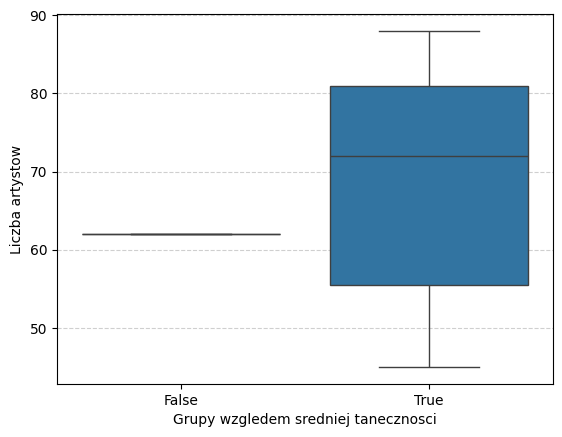

In [45]:
ax = sns.boxplot(
    data= eminem_df,
    x='explicit',
    y='popularity'
)

plt.grid(axis='y', linestyle='--', alpha=0.6) 
plt.xlabel('Grupy wzgledem sredniej tanecznosci')
plt.ylabel('Liczba artystow')
plt.show()

In [46]:
eminem_df["explicit"]

1069      True
1173      True
1201      True
1253      True
23270     True
26413     True
42220     True
42251     True
42302     True
42355     True
78159     True
78216     True
78277     True
78301     True
78320     True
78369     True
78401     True
78503     True
78523     True
78614     True
78939     True
90068    False
90117     True
90163     True
90200     True
90359     True
90361     True
90363     True
90462     True
90607     True
90706     True
90860     True
Name: explicit, dtype: bool